In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.layers import Dense
from tensorflow.keras import Model
from tensorflow.keras import layers
from tensorflow import keras

TensorFlow version: 2.5.0


In [2]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import csv
import pickle
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from datetime import datetime

In [3]:
from pathlib import Path
current_dir = os.path.join(Path().resolve())
sys.path.append(str(current_dir) + '/../')

In [4]:
from ReservoirRun import Reservoir
from evolver import DaccadBioneatMut, DaccadBioneatMut_5
from qdpy.containers import *
from individual import *

## Loading a dataset

In [5]:
myarray_np = np.loadtxt('../data/dataset_myarray_1.csv', delimiter=',')
mc_np = np.loadtxt('../data/dataset_mc_1.csv', delimiter=',')

In [13]:
myarray_np_1 = np.loadtxt('../data/print_jaco_3_myarray.csv', delimiter=',')
mc_np_1 = np.loadtxt('../data/print_jaco_3_data.csv', delimiter=',')
print(myarray_np_1.shape)
print(mc_np_1.shape)

(9999, 155)
(9999,)


In [14]:
myarray_np.shape

(1638, 155)

In [15]:
# save as a npz file
np.save('../data/myarray_2', myarray_np_1)
np.save('../data/mc_2', mc_np_1)

## Split into train data and test data as dataset

In [16]:
myarray_fullPath = os.path.abspath('../data/myarray_2.npy')
myarray_path = tf.keras.utils.get_file('myarray_2.npy', 'file://'+myarray_fullPath)
myarray_data = np.load(myarray_path)
#x_train, x_test = train_test_split(myarray_data, test_size=0.2)


mc_fullPath = os.path.abspath('../data/mc_2.npy')
mc_path = tf.keras.utils.get_file('mc_2.npy', 'file://'+mc_fullPath)
mc_data = np.load(mc_path)
#y_train, y_test = train_test_split(mc_data, test_size=0.2)
x_train, x_test, y_train, y_test = train_test_split(myarray_data, mc_data, test_size=0.2)

print(len(x_train), 'train examples')
print(len(x_test), 'test examples')
print(len(y_train), 'train examples')
print(len(y_test), 'test examples')

81920/80120 [==============================] - 0s 0us/step
7999 train examples
2000 test examples
7999 train examples
2000 test examples


In [17]:
x_train

array([[   9.06322134,    7.60978212,  124.53859286, ...,    0.        ,
           0.        ,    0.        ],
       [1000.        ,  399.12727581,  378.98865703, ...,    0.        ,
           0.        ,    0.        ],
       [   5.1       ,    5.1       ,  481.4766783 , ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [1000.        ,    5.1       ,   19.28882862, ...,    0.        ,
           0.        ,    0.        ],
       [  61.43582435,   39.66473078,    5.1       , ...,    0.        ,
           0.        ,    0.        ],
       [   5.1       ,    5.1       ,   87.41782966, ...,    0.        ,
           0.        ,    0.        ]])

In [18]:
myarray_data.shape

(9999, 155)

In [19]:
x_train.shape

(7999, 155)

In [20]:
# Add a channels dimension
#x_train = x_train[..., tf.newaxis]
#x_test = x_test[..., tf.newaxis]

In [21]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))

In [22]:
factor = [5*[1.0/1000.0]+150*[1.0/200.0]]
x_train = x_train * factor
x_test = x_test * factor

In [23]:
x_train = x_train[:, 0:30]
x_test = x_test[:, 0:30]

In [24]:
x_train

array([[0.00906322, 0.00760978, 0.12453859, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.39912728, 0.37898866, ..., 0.        , 0.        ,
        0.        ],
       [0.0051    , 0.0051    , 0.48147668, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.        , 0.0051    , 0.01928883, ..., 0.        , 0.        ,
        0.47298098],
       [0.06143582, 0.03966473, 0.0051    , ..., 0.        , 1.        ,
        0.        ],
       [0.0051    , 0.0051    , 0.08741783, ..., 0.        , 0.        ,
        0.        ]])

In [25]:
x_train = np.concatenate([x_train, np.mean(x_train[:, :5], axis=1).reshape((len(x_train), 1))], axis = 1)
x_test = np.concatenate([x_test, np.mean(x_test[:, :5], axis=1).reshape((len(x_test), 1))], axis = 1)
print(x_train)

[[0.00906322 0.00760978 0.12453859 ... 0.         0.         0.03781278]
 [1.         0.39912728 0.37898866 ... 0.         0.         0.75562319]
 [0.0051     0.0051     0.48147668 ... 0.         0.         0.39362119]
 ...
 [1.         0.0051     0.01928883 ... 0.         0.47298098 0.40631079]
 [0.06143582 0.03966473 0.0051     ... 1.         0.         0.06498599]
 [0.0051     0.0051     0.08741783 ... 0.         0.         0.23246326]]


In [26]:
x_train.shape

(7999, 31)

## Set my model

In [28]:
def build_model():
    model = tf.keras.Sequential([
        layers.Dense(15, activation='relu', input_shape=[31], use_bias=True),
        layers.Dense(10),
        layers.Dense(1, activation=lambda x: tf.math.abs(x))
    ])

    #optimizer = tf.keras.optimizers.RMSprop(0.001)
    optimizer = tf.keras.optimizers.Adam()

    model.compile(loss='mse',
                optimizer=optimizer,
                metrics=['mae', 'mse'])
    return model

In [29]:
model = build_model()

In [30]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 15)                480       
_________________________________________________________________
dense_1 (Dense)              (None, 10)                160       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 11        
Total params: 651
Trainable params: 651
Non-trainable params: 0
_________________________________________________________________


In [31]:
example_batch = x_train[:10]
example_result = model.predict(example_batch)
example_result

array([[0.11634775],
       [1.2668701 ],
       [0.9838426 ],
       [1.184963  ],
       [0.11465502],
       [0.75721204],
       [0.68309677],
       [0.49346936],
       [0.54951906],
       [0.7392473 ]], dtype=float32)

In [32]:
# エポックが終わるごとにドットを一つ出力することで進捗を表示
class PrintDot(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0: print('')
        print('.', end='')

# early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
EPOCHS = 400

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS, validation_split = 0.2, verbose=0,
    callbacks=[PrintDot()]
)


....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................

In [33]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mse,val_loss,val_mae,val_mse,epoch
395,48.453354,5.223077,48.453354,51.752300,5.327662,51.752300,395
396,48.573666,5.225042,48.573666,52.779007,5.470261,52.779007,396
397,48.533722,5.241211,48.533722,51.705425,5.325337,51.705425,397
398,48.376411,5.225756,48.376411,52.059063,5.340348,52.059063,398
399,48.450020,5.217304,48.450020,52.036598,5.346087,52.036598,399


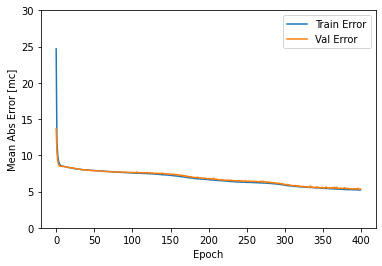

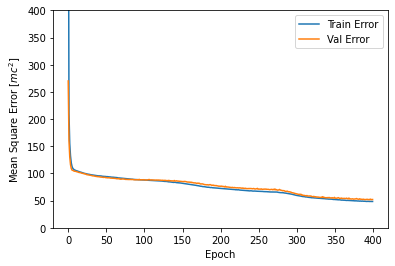

In [34]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [mc]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
    plt.ylim([0,30])
    plt.legend()

    plt.figure()
    plt.xlabel('Epoch')
    plt.ylabel('Mean Square Error [$mc^2$]')
    plt.plot(hist['epoch'], hist['mse'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mse'], label = 'Val Error')
    plt.ylim([0,400])
    plt.legend()
    plt.show()


plot_history(history)

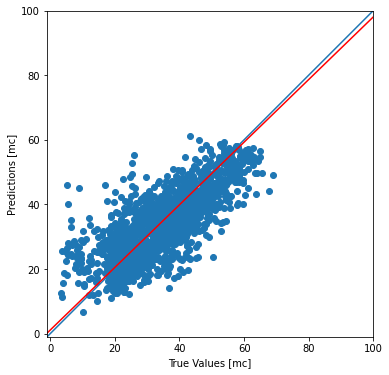

In [36]:
test_predictions = model.predict(x_test).flatten()
res = linregress(test_predictions, y_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [mc]')
plt.ylabel('Predictions [mc]')
plt.axis('equal')
plt.axis('square')
plt.xlim([-1,100])
plt.ylim([-1,100])
_ = plt.plot([-100, 100], [-100, 100])

plt.plot([-1, 100], res.intercept + res.slope*np.array([-1, 100]), 'r', label='fitted line')

In [37]:
np.corrcoef(y_test, test_predictions)

array([[1.        , 0.80228611],
       [0.80228611, 1.        ]])

In [42]:
# model.save('saved_model/my_model')

INFO:tensorflow:Assets written to: saved_model/my_model/assets


In [40]:
def calc_corrcoef(true_data_file, final_file_data):
    mc_predictions = []
    with open("../../results/reservoir_jacobian_surrogate/final_" + final_file_data + ".p", "rb") as f:
        data = pickle.load(f)
        for daccadIndiv in data['container']:
            daccadIndiv = np.array(daccadIndiv[0:30]).reshape([1, 30])
            daccadIndiv = np.concatenate([daccadIndiv, np.mean(daccadIndiv[:, :5], axis=1).reshape((len(daccadIndiv), 1))], axis = 1)
            mc_prediction = model.predict(daccadIndiv)
            mc_prediction = mc_prediction[0][0]
            mc_predictions.append(mc_prediction)

    with open('../../results/reservoir_jacobian_surrogate/' + true_data_file) as f:
        reader = csv.reader(f)
        reader = np.array(list(reader), dtype=float)
        reader = reader.reshape(len(reader))

        # plt.scatter(reader, mc_predictions)
        corrcoef = np.corrcoef(np.nan_to_num(reader), mc_predictions)
        print("corrcoef : ", corrcoef[0][1])

In [41]:
calc_corrcoef("mc_1_20220727130516.txt", "20220727130516")
calc_corrcoef("mc_2_20220728011411.txt", "20220728011411")
calc_corrcoef("mc_3_20220729022424.txt", "20220729022424")
calc_corrcoef("mc_4_20220731031909.txt", "20220731031909")
calc_corrcoef("mc_5_20221002222924.txt", "20221002222924")
calc_corrcoef("mc_6_20221003074016.txt", "20221003074016")
calc_corrcoef("mc_7_20221003091708.txt", "20221003091708")
calc_corrcoef("mc_8_20221003150137.txt", "20221003150137")
calc_corrcoef("mc_9_20221003165117.txt", "20221003165117")
calc_corrcoef("mc_10_20221004094630.txt", "20221004094630")
calc_corrcoef("mc_11_20221004230857.txt", "20221004230857")
calc_corrcoef("mc_12_20221006212207.txt", "20221006212207")
calc_corrcoef("mc_13_20221006212553.txt", "20221006212553")
calc_corrcoef("mc_14_20221027083500.txt", "20221027083500")
calc_corrcoef("mc_15_20221027085801.txt", "20221027085801")
calc_corrcoef("mc_16_20221027113259.txt", "20221027113259")
calc_corrcoef("mc_17_20221027150155.txt", "20221027150155")
calc_corrcoef("mc_18_20221103065336.txt", "20221103065336")
calc_corrcoef("mc_19_20221103131446.txt", "20221103131446")
calc_corrcoef("mc_20_20221106132932.txt", "20221106132932")
calc_corrcoef("mc_21_20221107024735.txt", "20221107024735")
calc_corrcoef("mc_22_20221107042313.txt", "20221107042313")
calc_corrcoef("mc_23_20221107160045.txt", "20221107160045")
calc_corrcoef("mc_24_20221108014113.txt", "20221108014113")
calc_corrcoef("mc_25_20221108043700.txt", "20221108043700")


corrcoef :  -0.13393597614041886
corrcoef :  0.4451609309558228
corrcoef :  0.4806671045524243
corrcoef :  -0.005978256382750481
corrcoef :  0.23441994548832365
corrcoef :  -0.006583808775772483
corrcoef :  0.1515405841247933
corrcoef :  -0.032204245069185775
corrcoef :  0.19395810059209623
corrcoef :  0.10231922813947844
corrcoef :  -0.05618244528332299
corrcoef :  -0.016470196003674057
corrcoef :  0.31971347007768547
corrcoef :  -0.0189063411415522
corrcoef :  0.1845131285502263
corrcoef :  0.1971398708457325
corrcoef :  0.06457605760860412
corrcoef :  0.6710965509643579
corrcoef :  0.7130824492985426
corrcoef :  0.4601107362926118
corrcoef :  0.4161192871233567
corrcoef :  0.3723659444247946
corrcoef :  0.5656252667748144
corrcoef :  0.5117968343065051
corrcoef :  0.44411512647149104
